In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#1.Compute the average prices and scores by Neighborhood;
# which borough is the most expensive on average? 
# Create a kernel density plot of price and log price, grouping by Neighborhood.

# --- Load dataset ---
# Read in the CSV file (make sure it's in the same folder)
df = pd.read_csv("NYC_Airbnb.csv")

# Clean column names 
df = df.rename(columns={"Neighbourhood ": "Neighborhood"})

# Check columns to confirm fix
print(df.columns)

Index(['Price', 'Review Scores Rating', 'Neighborhood', 'Property Type',
       'Room Type'],
      dtype='str')


In [ ]:
# --- Compute averages by Neighborhood ---
# Group by borough and compute mean Price and Review Scores
grouped = df.groupby("Neighborhood")[["Price", "Review Scores Rating"]].mean()
print(grouped)

#After grouping the data by Neighborhood and computing the average prices, Manhattan is the most expensive borough on average, with an average price of about 183.66 per night.
# Brooklyn and Staten Island are also relatively expensive, while the Bronx has the lowest average price. The review scores are fairly similar across boroughs, all around the low 90s.

                    Price  Review Scores Rating
Neighborhood                                   
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


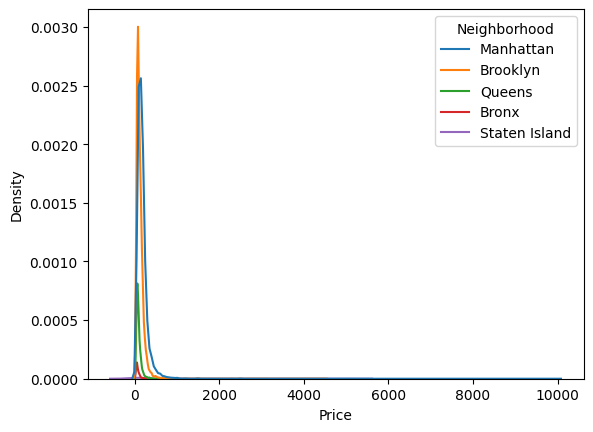

In [ ]:
# --- KDE plot for Price ---
sns.kdeplot(data=df, x="Price", hue="Neighborhood")  # distribution of price
plt.show()

In [ ]:
# --- Log transform ---
df["log_price"] = np.log(df["Price"] + 1)  # reduce skew

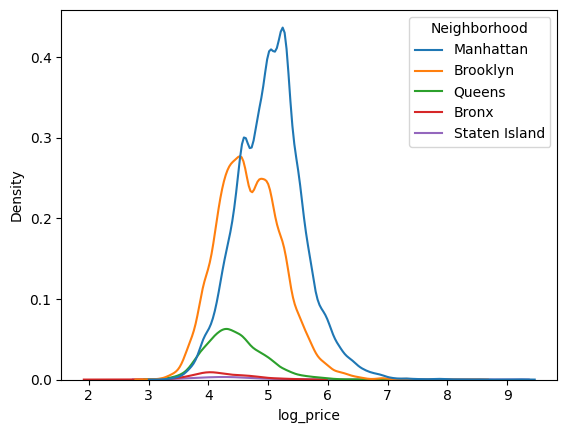

In [ ]:
# --- KDE plot for Log Price ---
sns.kdeplot(data=df, x="log_price", hue="Neighborhood")
plt.show()

In [ ]:
# Q2: Regress price on Neighborhood  by creating the appropriate dummy/one-hot-encoded variables,
# without an intercept in the linear model. 
# Compare the coefficients in the regression to the table from part 1. 
# What pattern do you see? 
# What are the coefficients in a regression of a continuous variable on one categorical variable?

# basically want to see if the regression gives the same averages computed before

# --- Create dummy variables for Neighborhood ---
# regression can't use text so we must Convert Brox, Brooklyn, Manhattan, Queens, Staten Island into dummy variables
# dummy variables are 0/1 indicators for each category

# drop_first=False keeps all columns, so we get a coefficient for each neighborhood instead of using one as a baseline
X = pd.get_dummies(df["Neighborhood"], drop_first=False)

#selects the thing we are predicting 
# X = inputs (Neighborhood); y = output (price)
y = df["Price"]

In [ ]:
# Fit linear regression model 
# fit_intercept=False means no baseline, no constant term; each coefficient will represent the average price for that neighborhood directly
model = LinearRegression(fit_intercept=False)

#this is where the model learns; looks at X (which neighborhood each row is) and y (price)
#and figures out what number should each neighborhood have
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print(model.coef_)

[ 75.2764977  127.74737834 183.66428632  96.8572327  146.16666667]


In [ ]:
print(X.columns)

Index(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'], dtype='str')


In [ ]:
#Q3: Repeat part 2, but leave an intercept in the linear model. 
# How do you have to handle the creation of the dummies differently? 
# What is the intercept? Interpret the coefficients. 
# How can I get the coefficients in part 2 from these new coefficients?

# with intercept, we need to drop one dummy variable to avoid the dummy variable trap.

#drop_first=True means we drop the first category (Bronx) and use it as the baseline.
X = pd.get_dummies(df["Neighborhood"], drop_first=drop_first)

#selects the thing we are predicting 
# X = inputs (Neighborhood); y = output (price)
y = df["Price"]

NameError: name 'drop_first' is not defined

In [ ]:
# Fit linear regression model with intercept

model = LinearRegression() #intercept is included by default
model.fit(X,y)

#Results
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_) 

Intercept: 125.9424123463574
Coefficients: [-50.66591465   1.804966    57.72187398 -29.08517964  20.22425432]


In [ ]:
# Fit linear regression model with intercept

model = LinearRegression() #intercept is included by default
model.fit(X,y)

#Results
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_) 
print("Columns:", X.columns)

Intercept: 125.9424123463574
Coefficients: [-50.66591465   1.804966    57.72187398 -29.08517964  20.22425432]
Columns: Index(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'], dtype='str')


In [ ]:
#Q3: Repeat part 2, but leave an intercept in the linear model. 
# How do you have to handle the creation of the dummies differently? 
# What is the intercept? Interpret the coefficients. 
# How can I get the coefficients in part 2 from these new coefficients?

# with intercept, we need to drop one dummy variable to avoid the dummy variable trap.

#drop_first=True means we drop the first category (Bronx) and use it as the baseline.
X = pd.get_dummies(df["Neighborhood"], drop_first=drop_first)

#selects the thing we are predicting 
# X = inputs (Neighborhood); y = output (price)
y = df["Price"]

NameError: name 'drop_first' is not defined

In [ ]:
#Q3: Repeat part 2, but leave an intercept in the linear model. 
# How do you have to handle the creation of the dummies differently? 
# What is the intercept? Interpret the coefficients. 
# How can I get the coefficients in part 2 from these new coefficients?

# with intercept, we need to drop one dummy variable to avoid the dummy variable trap.

#drop_first=True means we drop the first category (Bronx) and use it as the baseline.
X = pd.get_dummies(df["Neighborhood"], drop_first=drop_first)

#selects the thing we are predicting 
# X = inputs (Neighborhood); y = output (price)
y = df["Price"]

NameError: name 'drop_first' is not defined

In [ ]:
# Fit linear regression model with intercept

model = LinearRegression() #intercept is included by default
model.fit(X,y)

#Results
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_) 
print("Columns:", X.columns)

Intercept: 125.9424123463574
Coefficients: [-50.66591465   1.804966    57.72187398 -29.08517964  20.22425432]
Columns: Index(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'], dtype='str')


In [ ]:
#Q3: Repeat part 2, but leave an intercept in the linear model. 
# How do you have to handle the creation of the dummies differently? 
# What is the intercept? Interpret the coefficients. 
# How can I get the coefficients in part 2 from these new coefficients?

# with intercept, we need to drop one dummy variable to avoid the dummy variable trap.

#drop_first=True means we drop the first category (Bronx) and use it as the baseline.
X = pd.get_dummies(df["Neighborhood"], drop_first=True)

#selects the thing we are predicting 
# X = inputs (Neighborhood); y = output (price)
y = df["Price"]

In [ ]:
# Fit linear regression model with intercept

model = LinearRegression() #intercept is included by default
model.fit(X,y)

#Results
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_) 
print("Columns:", X.columns)

Intercept: 75.27649769585331
Coefficients: [ 52.47088065 108.38778863  21.58073501  70.89016897]
Columns: Index(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island'], dtype='str')


In [ ]:
#Q4: Split the sample 80/20 into a training and a test set. Run a regression of Price on Review Scores Rating and Neighborhood . 
# What is the R^2 and RMSE on the test set? 
# What is the coefficient on Review Scores Rating? 
# What is the most expensive kind of property you can rent?

#asked to: split data --> train/test
#regress price on: review scores rating (numeric) and neighborhood (categorical --> dummies)
#evaluate on test set: R^2, RMSE
#Interpret coefficient on review scores rating
#Find most expensive kind of property 

#create dummy variables for Neighborhood, drop one for baseline
X = pd.get_dummies(df[["Review Scores Rating", "Neighborhood"]], drop_first=True)

#target variable
y = df["Price"]

In [ ]:
# split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Fit Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#Predictions on test set
y+pred = model.predict(X_test)

#Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R^2 on test set:", r2)
print("RMSE on test set:", rmse)

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (<ipython-input-35-270cd719cc56>, line 3)

In [ ]:
#Q4: Split the sample 80/20 into a training and a test set. Run a regression of Price on Review Scores Rating and Neighborhood . 
# What is the R^2 and RMSE on the test set? 
# What is the coefficient on Review Scores Rating? 
# What is the most expensive kind of property you can rent?

#asked to: split data --> train/test
#regress price on: review scores rating (numeric) and neighborhood (categorical --> dummies)
#evaluate on test set: R^2, RMSE
#Interpret coefficient on review scores rating
#Find most expensive kind of property 

#create dummy variables for Neighborhood, drop one for baseline
X = pd.get_dummies(df[["Review Scores Rating", "Neighborhood"]], drop_first=True)

#target variable
y = df["Price"]

In [ ]:
# split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Fit Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#Predictions on test set
y_pred = model.predict(X_test)

#Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R^2 on test set:", r2)
print("RMSE on test set:", rmse)

R^2 on test set: 0.045925883817350965
RMSE on test set: 140.91821103729345


In [ ]:
# Coefficients 
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})
print(coef_df)

print("Intercept:", model.intercept_)

                     Variable  Coefficient
0        Review Scores Rating     1.211852
1       Neighborhood_Brooklyn    51.555970
2      Neighborhood_Manhattan   107.413553
3         Neighborhood_Queens    20.198573
4  Neighborhood_Staten Island    23.454672
Intercept: -35.157344063247564


In [ ]:
# Coefficients 
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})
print(coef_df)

print("Intercept:", model.intercept_)

#ANSWER:
#The R² on the test set is about 0.046, and the RMSE is about 140.92, indicating that the model does not explain much of the variation in price.
# The coefficient on Review Scores Rating is about 1.21, meaning that for each one-point increase in rating, the price increases by about $1.21, holding neighborhood constant.
#The most expensive neighborhood is Manhattan, since it has the largest positive coefficient (about 107.41) relative to the baseline (Bronx).
#Compared to the previous model, the neighborhood coefficients are smaller, suggesting that some of the differences in price across neighborhoods are explained by review scores.

                     Variable  Coefficient
0        Review Scores Rating     1.211852
1       Neighborhood_Brooklyn    51.555970
2      Neighborhood_Manhattan   107.413553
3         Neighborhood_Queens    20.198573
4  Neighborhood_Staten Island    23.454672
Intercept: -35.157344063247564


In [ ]:
#Q5: Run a regression of Price on Review Scores Rating and Neighborhood  and Property Type. 
# What is the R^2 and RMSE on the test set? 
# What is the coefficient on Review Scores Rating? 
# What is the most expensive kind of property you can rent?

#now we make the model include property type as well, which is another categorical variable that we need to convert to dummies

# create dummy variables for Neighborhood and Property Type, drop one for baseline
X = pd.get_dummies(df[["Review Scores Rating", "Neighborhood", "Property Type"]], drop_first=True)

#create target variable
y = df["Price"]

In [ ]:
# split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Fit in the model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#Predictions on test set
y_pred = model.predict(X_test)

In [ ]:
#Evaluate model performance

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R^2 on test set:", r2)
print("RMSE on test set:", rmse)    

R^2 on test set: 0.054242713551245325
RMSE on test set: 140.30266238276283


In [ ]:
# Coefficients
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})
print(coef_df)      

print("Intercept:", model.intercept_)

                         Variable  Coefficient
0            Review Scores Rating     1.201011
1           Neighborhood_Brooklyn    59.633702
2          Neighborhood_Manhattan   121.005520
3             Neighborhood_Queens    26.830617
4      Neighborhood_Staten Island    15.700974
5   Property Type_Bed & Breakfast   -28.703920
6              Property Type_Boat    47.070419
7          Property Type_Bungalow    83.972440
8             Property Type_Cabin    12.389621
9         Property Type_Camper/RV   -13.817125
10           Property Type_Castle   -41.810548
11           Property Type_Chalet   -30.237720
12      Property Type_Condominium    61.907162
13             Property Type_Dorm   -42.277758
14            Property Type_House    34.711346
15              Property Type_Hut  -134.604484
16       Property Type_Lighthouse   -91.438731
17             Property Type_Loft    69.891025
18            Property Type_Other    49.249761
19        Property Type_Townhouse    44.110768
20        Pro

In [ ]:
#Q6: What does the coefficient on Review Scores Rating mean if it changes from part 4 to 5?
#  Hint: Think about how multiple linear regression works.

#asking why did the coefficient on review scores rating change when you added property type
#idea: in multiple linear regressions -each coefficient is interpreted holding all other variables constant 
# what changed from 4 to 5?
# 4: controlled for neighborhood only
# 5: controlled for neighborhood and property type
# so now the model separates: effects of ratings and effects of property type 

#ANSWER:
# The coefficient on Review Scores Rating changes from part 4 to part 5 because the model now includes an additional variable, Property Type. 
# In multiple linear regression, each coefficient represents the effect of that variable while holding all other variables constant.
# In part 4, the coefficient on review scores may have captured some of the effect of property type. 
# In part 5, after adding Property Type to the model, the coefficient on review scores reflects its effect after accounting for both neighborhood and property type. 
# This change shows that some of the variation previously attributed to review scores is actually explained by property type.

In [ ]:
#Q7:We've included Neighborhood  and Property Type separately in the model. 
# How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". 
# Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus Review Scores Rating. 
# How does the slope coefficient for Review Scores Rating, the R^2and the RMSE change? 
# Do they increase significantly compares to part 5? 
# Are the coefficients in this regression just the sum of the coefficients for Neighbourhood  and Property Type from 5? 
# What is the most expensive kind of property you can rent?

# instead of treating: neighborhood, property type
# seperately commbinations like Bungalow in Manhattan, Townhouse in Queens, etc.

#create inetraction variable 
#combine neighborhood and property type into one column
df["Interaction"] = df["Neighborhood"] + "_" + df["Property Type"]

#create dummies and drop one for baseline
X = pd.get_dummies(df[["Review Scores Rating", "Interaction"]], drop_first=True)

# target variable
y = df["Price"]

In [ ]:
# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# --- Fit model ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

In [ ]:
# --- Evaluation ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R^2:", r2)
print("RMSE:", rmse)

R^2: 0.054558809011926446
RMSE: 140.27921411459116


In [ ]:
# --- Coefficients ---
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})
print(coef_df)

print("Intercept:", model.intercept_)

                                     Variable   Coefficient
0                        Review Scores Rating  1.199018e+00
1           Interaction_Bronx_Bed & Breakfast -2.084589e+01
2               Interaction_Bronx_Condominium  6.513447e+01
3                     Interaction_Bronx_House -4.180558e+00
4                      Interaction_Bronx_Loft  5.294650e+01
5                 Interaction_Bronx_Townhouse  3.254724e+01
6              Interaction_Brooklyn_Apartment  4.714598e+01
7        Interaction_Brooklyn_Bed & Breakfast  1.073713e+01
8                   Interaction_Brooklyn_Boat  3.012701e-12
9              Interaction_Brooklyn_Camper/RV -2.166160e+01
10                Interaction_Brooklyn_Chalet  1.435313e+01
11           Interaction_Brooklyn_Condominium  9.549213e+01
12                  Interaction_Brooklyn_Dorm  7.935002e+00
13                 Interaction_Brooklyn_House  7.992697e+01
14            Interaction_Brooklyn_Lighthouse -4.684589e+01
15                  Interaction_Brooklyn

Connected to venv (Python 3.12.1)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#QUESTION 2 SET

#Q1: Load cars_hw.csv. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) 
# Note this is different than normalizing: there is a text below that explains further. 
# Clean the data however you think is most appropriate

# --- Load dataset ---
df = pd.read_csv("cars_hw.csv")

# --- Check data ---
print(df.head())
print(df.describe())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
       Unnamed: 0    Make_Year  

In [ ]:
#QUESTION 2 SET

#Q1: Load cars_hw.csv. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) 
# Note this is different than normalizing: there is a text below that explains further. 
# Clean the data however you think is most appropriate

# --- Load dataset ---
df = pd.read_csv("cars_hw.csv")

# --- Check data ---
print(df.head())
print(df.describe())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
       Unnamed: 0    Make_Year  

In [ ]:
# --- Drop unnecessary column ---
# "Unnamed: 0" is just an index column and does not contain useful information
df = df.drop(columns=["Unnamed: 0"])

# --- Fix No_of_Owners ---
# This column is stored as text (e.g., "1st", "2nd"), which cannot be used in regression
# We remove the text and keep only the numeric part, then convert to integers
df["No_of_Owners"] = df["No_of_Owners"].str.replace(r"\D", "", regex=True).astype(int)

# --- Handle skewed variables ---
# Price and Mileage_Run are right-skewed (many small values, few very large ones)
# Taking the log compresses large values and makes the distribution more symmetric
df["log_price"] = np.log(df["Price"] + 1)
df["log_mileage"] = np.log(df["Mileage_Run"] + 1)

# --- Remove extreme outliers ---
# Very large prices can distort the model, so we remove the top 1% of values
price_cutoff = df["Price"].quantile(0.99)
df = df[df["Price"] < price_cutoff]

KeyError: "['Unnamed: 0'] not found in axis"

In [ ]:
#QUESTION 2 SET

#Q1: Load cars_hw.csv. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) 
# Note this is different than normalizing: there is a text below that explains further. 
# Clean the data however you think is most appropriate

# --- Load dataset ---
df = pd.read_csv("cars_hw.csv")

# --- Check data ---
print(df.head())
print(df.describe())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
       Unnamed: 0    Make_Year  

In [ ]:
# --- Drop unnecessary column ---
# "Unnamed: 0" is just an index column and does not contain useful information
df = df.drop(columns=["Unnamed: 0"])

# --- Fix No_of_Owners ---
# This column is stored as text (e.g., "1st", "2nd"), which cannot be used in regression
# We remove the text and keep only the numeric part, then convert to integers
df["No_of_Owners"] = df["No_of_Owners"].str.replace(r"\D", "", regex=True).astype(int)

# --- Handle skewed variables ---
# Price and Mileage_Run are right-skewed (many small values, few very large ones)
# Taking the log compresses large values and makes the distribution more symmetric
df["log_price"] = np.log(df["Price"] + 1)
df["log_mileage"] = np.log(df["Mileage_Run"] + 1)

# --- Remove extreme outliers ---
# Very large prices can distort the model, so we remove the top 1% of values
price_cutoff = df["Price"].quantile(0.99)
df = df[df["Price"] < price_cutoff]

In [ ]:
# --- Check cleaned data ---
# This helps confirm that the data looks more reasonable after cleaning
print(df.describe())

         Make_Year   Mileage_Run  No_of_Owners  Seating_Capacity  \
count   966.000000    966.000000    966.000000        966.000000   
mean   2016.927536  41646.677019      1.167702          5.094203   
std       2.810588  24464.647066      0.384724          0.444223   
min    2011.000000   1117.000000      1.000000          4.000000   
25%    2015.000000  22624.250000      1.000000          5.000000   
50%    2017.000000  37677.000000      1.000000          5.000000   
75%    2019.000000  57987.250000      1.000000          5.000000   
max    2022.000000  99495.000000      3.000000          8.000000   

              Price   log_price  log_mileage  
count  9.660000e+02  966.000000   966.000000  
mean   7.268965e+05   13.399217    10.417238  
std    3.406196e+05    0.437111     0.735156  
min    1.880000e+05   12.144203     7.019297  
25%    4.727500e+05   13.066320    10.026820  
50%    6.625000e+05   13.403777    10.536831  
75%    8.747500e+05   13.681691    10.967996  
max    1.97

In [ ]:
#Q2:Summarize the Price variable and create a kernel density plot. 
# Use .groupby() and .describe() to summarize prices by brand (Make). 
# Make a grouped kernel density plot by Make. 
# Which car brands are the most expensive? What do prices look like in general?
#Split the data into an 80% training set and a 20% testing set.

# --- Summarize Price ---
# describe() gives count, mean, std, min, max, etc.
print(df["Price"].describe())

count    9.660000e+02
mean     7.268965e+05
std      3.406196e+05
min      1.880000e+05
25%      4.727500e+05
50%      6.625000e+05
75%      8.747500e+05
max      1.978000e+06
Name: Price, dtype: float64


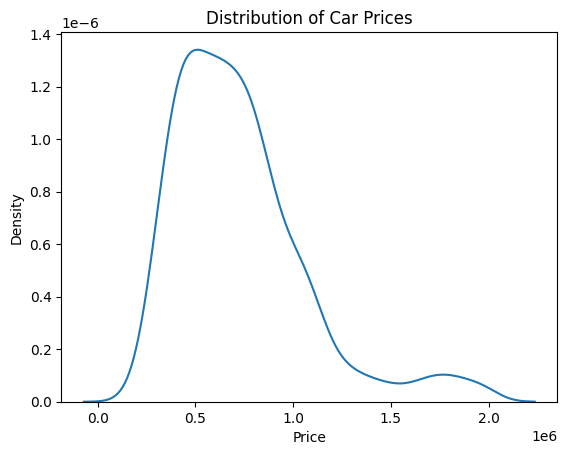

In [ ]:
#  KDE plot for Price 
# Shows distribution (shape) of price
sns.kdeplot(df["Price"])
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.show()

In [ ]:
#  Group by Make (brand) 
# groupby() groups data by brand
# describe() summarizes price within each brand
price_by_make = df.groupby("Make")["Price"].describe()
print(price_by_make)

               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        6.0  4.535000e+05  246606.366503   267000.0   288500.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Honda           73.0  7.989726e+05  266509.066586   316000.0   581000.0   
Hyundai        305.0  6.918918e+05  279159.708519   248000.0   485000.0   
Jeep             4.0  1.499500e+06  152513.387391  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  119056.709177  1369000.0  1579000.0   
MG Motors       27.0  1.830333e+06  110937.959100  1589000.0  1767000.0   
Mahindra        18.0  1.100167e+06  175549.305961   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  216019.860943   237000.0   411000.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Renault         68.0  6.6

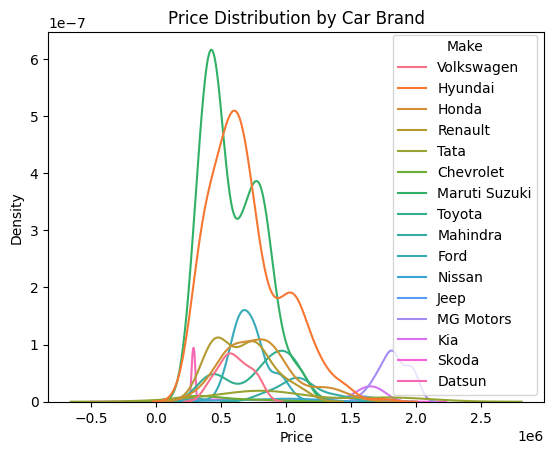

In [ ]:
# --- KDE plot grouped by Make ---
# Shows how price distributions differ by brand
sns.kdeplot(data=df, x="Price", hue="Make")
plt.title("Price Distribution by Car Brand")
plt.xlabel("Price")
plt.show()

In [ ]:
# --- Train/Test Split (80/20) ---
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Price"])  # predictors
y = df["Price"]                # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

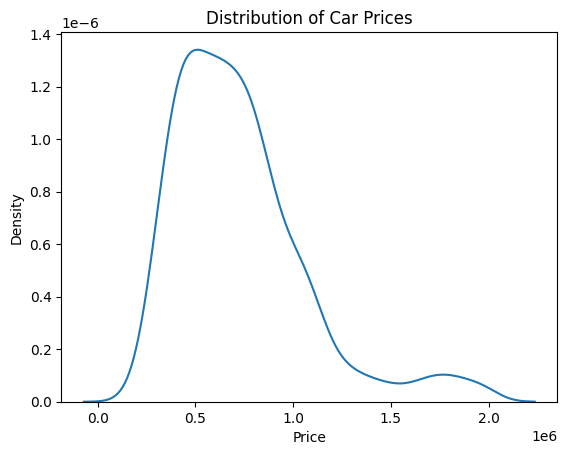

In [ ]:
#  KDE plot for Price 
# Shows distribution (shape) of price
sns.kdeplot(df["Price"])
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.show()

In [ ]:
#  Group by Make (brand) 
# groupby() groups data by brand
# describe() summarizes price within each brand
price_by_make = df.groupby("Make")["Price"].describe()
print(price_by_make)

               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        6.0  4.535000e+05  246606.366503   267000.0   288500.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Honda           73.0  7.989726e+05  266509.066586   316000.0   581000.0   
Hyundai        305.0  6.918918e+05  279159.708519   248000.0   485000.0   
Jeep             4.0  1.499500e+06  152513.387391  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  119056.709177  1369000.0  1579000.0   
MG Motors       27.0  1.830333e+06  110937.959100  1589000.0  1767000.0   
Mahindra        18.0  1.100167e+06  175549.305961   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  216019.860943   237000.0   411000.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Renault         68.0  6.6

In [ ]:
#  Group by Make (brand) 
# groupby() groups data by brand
# describe() summarizes price within each brand
price_by_make = df.groupby("Make")["Price"].describe()
print(price_by_make)

               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        6.0  4.535000e+05  246606.366503   267000.0   288500.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Honda           73.0  7.989726e+05  266509.066586   316000.0   581000.0   
Hyundai        305.0  6.918918e+05  279159.708519   248000.0   485000.0   
Jeep             4.0  1.499500e+06  152513.387391  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  119056.709177  1369000.0  1579000.0   
MG Motors       27.0  1.830333e+06  110937.959100  1589000.0  1767000.0   
Mahindra        18.0  1.100167e+06  175549.305961   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  216019.860943   237000.0   411000.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Renault         68.0  6.6

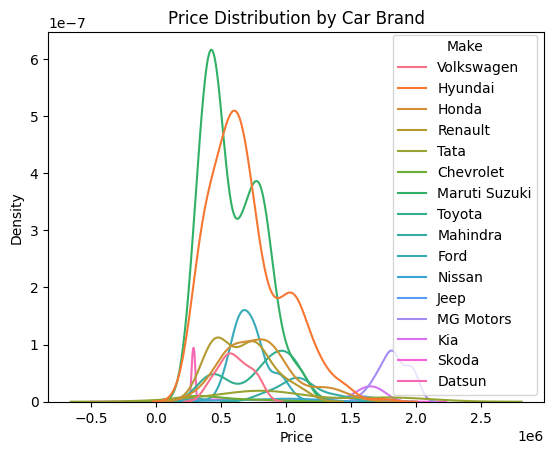

In [ ]:
#  KDE plot grouped by Make 
# Shows how price distributions differ by brand
sns.kdeplot(data=df, x="Price", hue="Make")
plt.title("Price Distribution by Car Brand")
plt.xlabel("Price")
plt.show()

In [ ]:
#Q3: Split the data into an 80% training set and a 20% testing set.

#  Train/Test Split (80/20) 
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Price"])  # predictors
y = df["Price"]                # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Q4:Make a model where you regress price on the numeric variables alone; what is the R^2 and RMSE on the training set and test set? 
# Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone
#  (you can use pd.get_dummies(); be careful of the dummy variable trap); 
# what is the R^2 and RMSE on the test set? Which model performs better on the test set? 
# Make a third model that combines all the regressors from the previous two; 
# what is the R^2 and RMSE on the test set? 
# Does the joint model perform better or worse, and by home much?

In [ ]:
# --- Model 1: Numeric variables only ---

# Select numeric features (these are already numbers)
X = df[["Make_Year", "Mileage_Run", "No_of_Owners", "Seating_Capacity"]]

# Target variable we want to predict
y = df["Price"]

# Split data into training (80%) and testing (20%)
# Training data is used to fit the model, testing data evaluates performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create linear regression model
model = LinearRegression()

# Fit the model (learn relationship between X and y)
model.fit(X_train, y_train)

# Make predictions on training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Compute performance metrics
# R^2 measures how much variation in price is explained by the model
# RMSE measures average prediction error in dollars
print("Numeric Model Train R^2:", r2_score(y_train, y_train_pred))
print("Numeric Model Test R^2:", r2_score(y_test, y_test_pred))

print("Numeric Model Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Numeric Model Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Numeric Model Train R^2: 0.32170405868405905
Numeric Model Test R^2: 0.27211197364012485
Numeric Model Train RMSE: 283611.6053180997
Numeric Model Test RMSE: 276598.06414127885


In [ ]:
# --- Model 2: Categorical variables only ---

# Convert categorical variables into dummy (0/1) variables
# drop_first=True avoids multicollinearity (dummy variable trap)
X = pd.get_dummies(df[["Make", "Color", "Body_Type", "Fuel_Type", "Transmission_Type"]], drop_first=True)

# Target variable remains the same
y = df["Price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_test_pred = model.predict(X_test)

# Evaluate performance
print("Categorical Model Test R^2:", r2_score(y_test, y_test_pred))
print("Categorical Model Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Categorical Model Test R^2: 0.6212991056791745
Categorical Model Test RMSE: 199510.15862491645


In [ ]:
# --- Model 3: Combined numeric + categorical variables ---

# Combine numeric and categorical features into one dataset
X_num = df[["Make_Year", "Mileage_Run", "No_of_Owners", "Seating_Capacity"]]
X_cat = pd.get_dummies(df[["Make", "Color", "Body_Type", "Fuel_Type", "Transmission_Type"]], drop_first=True)

X = pd.concat([X_num, X_cat], axis=1)

# Target variable
y = df["Price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_test_pred = model.predict(X_test)

# Evaluate performance
print("Combined Model Test R^2:", r2_score(y_test, y_test_pred))
print("Combined Model Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Combined Model Test R^2: 0.7788381950832297
Combined Model Test RMSE: 152465.6155033023


In [ ]:
#ANSWER:
# The numeric-only model has a training R² of about 0.322 and a test R² of about 0.272. The RMSE is approximately 283,612 on the training set and 276,598 on the test set. This indicates that numeric variables alone explain a limited portion of the variation in car prices.

#The categorical-only model has a test R² of about 0.621 and an RMSE of about 199,510. This model performs substantially better than the numeric model, suggesting that categorical variables such as Make and Body_Type are strong predictors of price.

#The combined model has a test R² of about 0.779 and an RMSE of about 152,466. This model performs the best, as it incorporates both numeric and categorical variables.

#Overall, the combined model improves performance significantly compared to the individual models. The R² increases from 0.621 to 0.779 and the RMSE decreases from about 199,510 to 152,466, showing that combining both types of variables provides a much better fit.

In [ ]:
#Q5: Use the PolynomialFeatures function from sklearn to expand the set of numerical variables you're using in the regression. 
# As you increase the degree of the expansion, how do the R^2and RMSE change? 
# At what point does R^2 go negative on the test set? 
# For your best model with expanded features, what is the R^2 and RMSE? 
# How does it compare to your best model from part 4?

#degree 1 → original variables
#degree 2 → squares + interactions
#degree 3 → more complex terms
#Then see how performance change

In [ ]:
#  Polynomial regression with numeric variables only 

# Use the same numeric variables from the earlier model
X = df[["Make_Year", "Mileage_Run", "No_of_Owners", "Seating_Capacity"]]
y = df["Price"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Try several polynomial degrees
for degree in [1, 2, 3, 4, 5]:
    
    # PolynomialFeatures creates squared terms, cubic terms, and interactions
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    
    # Fit on training data and transform both train and test sets
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Fit linear regression model on expanded features
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predict on the test set
    y_test_pred = model.predict(X_test_poly)
    
    # Compute test performance
    r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    print("Degree:", degree)
    print("Test R^2:", r2)
    print("Test RMSE:", rmse)
    print()

Degree: 1
Test R^2: 0.27211197364012485
Test RMSE: 276598.06414127885

Degree: 2
Test R^2: 0.30159539636537014
Test RMSE: 270938.2961103817

Degree: 3
Test R^2: 0.29674345635430255
Test RMSE: 271877.7952922088

Degree: 4
Test R^2: 0.30778490205182196
Test RMSE: 269735.0493433084

Degree: 5
Test R^2: 0.29667064522151476
Test RMSE: 271891.8692585846



In [ ]:
#Q6: For your best model so far, determine the predicted values for the test data and plot them against the true values.
# Do the predicted values and true values roughly line up along the diagonal, or not? 
# Compute the residuals/errors for the test data and create a kernel density plot. 
# Do the residuals look roughly bell-shaped around zero?
# Evaluate the strengths and weaknesses of your model.

# Use best model (combined variables) 

# Recreate combined features
X_num = df[["Make_Year", "Mileage_Run", "No_of_Owners", "Seating_Capacity"]]
X_cat = pd.get_dummies(df[["Make", "Color", "Body_Type", "Fuel_Type", "Transmission_Type"]], drop_first=True)

X = pd.concat([X_num, X_cat], axis=1)
y = df["Price"]

# Train/test split (same as before)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

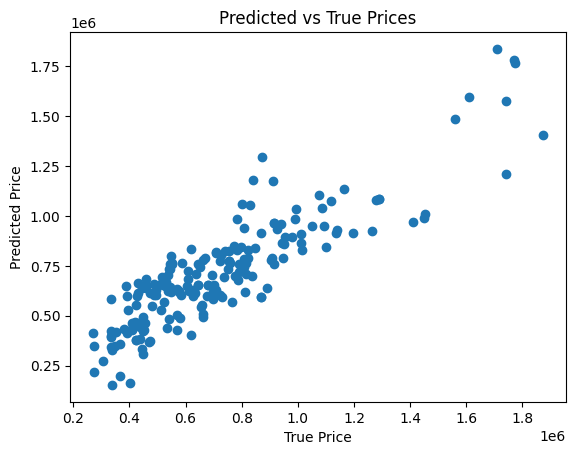

In [ ]:
#  Plot predicted vs actual values 
# If model is good, points should lie near the diagonal line
plt.scatter(y_test, y_pred)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True Prices")
plt.show()

In [ ]:
#  Compute residuals 
# residual = actual - predicted
residuals = y_test - y_pred

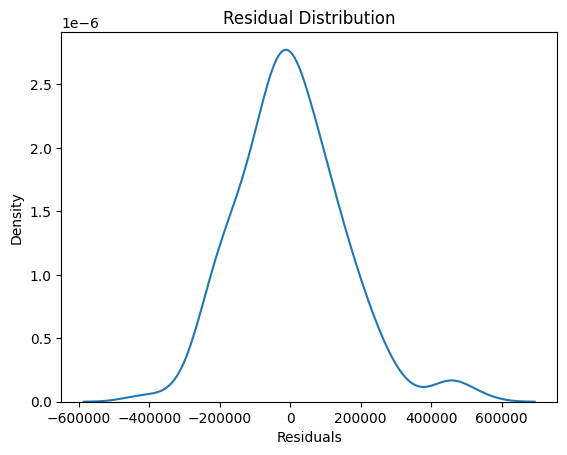

In [ ]:
#  Plot residual distribution 
# Should be roughly centered around 0 if model is good
sns.kdeplot(residuals)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

In [ ]:
#QUESTION 3 SET

#Q1: Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

# For this question, I selected a dataset on student performance factors. The dataset includes variables such as Hours_Studied, Attendance, Sleep_Hours, Motivation_Level, and other demographic and behavioral factors, with Exam_Score as the target variable.

#I chose this dataset because it contains both numeric and categorical variables, making it well-suited for applying linear regression techniques similar to those used in previous questions. It also allows for analyzing how different factors influence academic performance.

# Load dataset 
df = pd.read_csv("StudentPerformanceFactors.csv")

#  Check data 
print(df.head())
print(df.info())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [ ]:
#QUESTION 3 SET

#Q1: Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

# For this question, I selected a dataset on student performance factors. The dataset includes variables such as Hours_Studied, Attendance, Sleep_Hours, Motivation_Level, and other demographic and behavioral factors, with Exam_Score as the target variable.

#I chose this dataset because it contains both numeric and categorical variables, making it well-suited for applying linear regression techniques similar to those used in previous questions. It also allows for analyzing how different factors influence academic performance.

# Load dataset 
df = pd.read_csv("StudentPerformanceFactors.csv")

#  Check data 
print(df.head())
print(df.info())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [ ]:
#Q2: Clean the data and do some exploratory data analysis on key variables that interest you. 
# Pick a particular target/outcome variable and features/predictors.
# Clean data 
# Drop rows with missing values to keep things simple
df = df.dropna()

In [ ]:
#  Convert categorical variables 
# Turn all text variables into dummy (0/1) variables
df = pd.get_dummies(df, drop_first=True)

In [ ]:
#QUESTION 3 SET

#Q1: Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

# For this question, I selected a dataset on student performance factors. The dataset includes variables such as Hours_Studied, Attendance, Sleep_Hours, Motivation_Level, and other demographic and behavioral factors, with Exam_Score as the target variable.

#I chose this dataset because it contains both numeric and categorical variables, making it well-suited for applying linear regression techniques similar to those used in previous questions. It also allows for analyzing how different factors influence academic performance.

# Load dataset 
df = pd.read_csv("StudentPerformanceFactors.csv")

#  Check data 
print(df.head())
print(df.info())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [ ]:
#Q2: Clean the data and do some exploratory data analysis on key variables that interest you. 
# Pick a particular target/outcome variable and features/predictors.
# Clean data 
# Drop rows with missing values to keep things simple
df = df.dropna()

In [ ]:
#  Convert categorical variables 
# Turn all text variables into dummy (0/1) variables
df = pd.get_dummies(df, drop_first=True)

In [ ]:
#  Define target and predictors 
# Target variable (what we want to predict)
y = df["Exam_Score"]

# Predictor variables (everything else)
X = df.drop(columns=["Exam_Score"])

In [ ]:
#  Summary of target variable 
print(y.describe())

count    6378.000000
mean       67.252117
std         3.914217
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


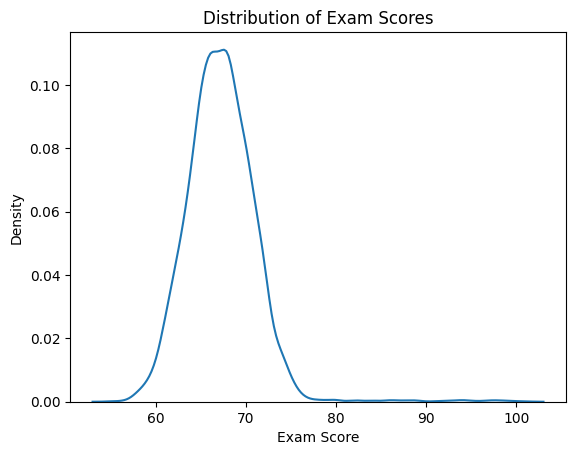

In [ ]:
#  Distribution of Exam Score 
sns.kdeplot(y)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.show()

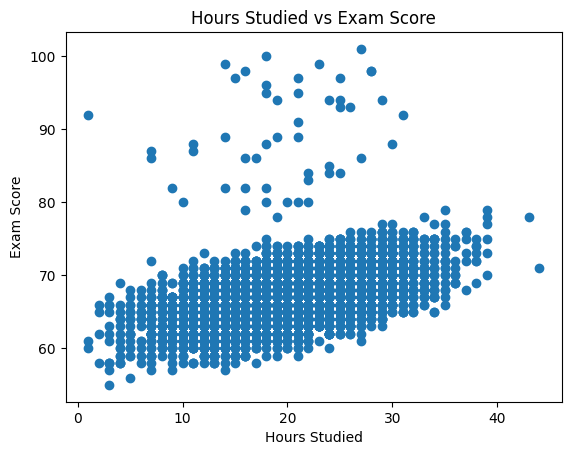

In [ ]:
# Relationship: Hours Studied vs Exam Score 
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

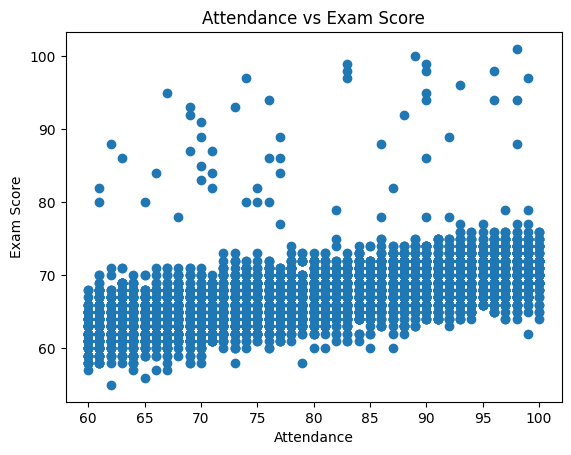

In [ ]:
#  Relationship: Attendance vs Exam Score 
plt.scatter(df["Attendance"], df["Exam_Score"])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")
plt.show()

In [ ]:
# ANSWER: 
# I cleaned the dataset by removing observations with missing values in variables such as Teacher_Quality, Parental_Education_Level, and Distance_from_Home. This ensures that the dataset is complete and suitable for regression analysis. I also converted all categorical variables into dummy variables using one-hot encoding so they can be used in a linear regression model.
# I selected Exam_Score as the target variable, since it represents student academic performance. The predictor variables include factors such as Hours_Studied, Attendance, Sleep_Hours, Previous_Scores, and other demographic and behavioral characteristics.

# From the summary statistics, Exam_Score has a mean of about 67.25 with a standard deviation of about 3.91, indicating that most students’ scores are relatively close to the average. The distribution of exam scores appears approximately bell-shaped, with most values concentrated between about 65 and 70, and a few higher outliers.

# The scatter plot of Hours_Studied versus Exam_Score shows a positive relationship, where students who study more hours tend to have higher exam scores. Similarly, the scatter plot of Attendance versus Exam_Score also shows a positive relationship, indicating that higher attendance is associated with better performance.
#Overall, the exploratory analysis suggests that both study time and attendance are important predictors of exam scores, and the selected variables are appropriate for modeling student performance using linear regression.

In [ ]:
#3.Split the sample into an ~80% training set and a ~20% test set.

In [ ]:
#4. Run a few regressions of your target/outcome variable on a variety of features/predictors. 
# Compute the RMSE on the test set.

In [ ]:
#5. Which model performed the best, and why?

In [ ]:
#6. What did you learn?

In [ ]:
#3.Split the sample into an ~80% training set and a ~20% test set.

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.2, random_state=42)

# Check sizes
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 5102
Test set size: 1276


In [ ]:
#3.Split the sample into an ~80% training set and a ~20% test set.

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.2, random_state=42)

# Check sizes
print("Training set size:", X_train.shape[0]) #51
print("Test set size:", X_test.shape[0]) #1276

#I split the dataset into an 80% training set and a 20% test set using the train_test_split function. The training set is used to fit the linear regression model, while the test set is used to evaluate how well the model performs on unseen data.

#I used a random_state of 42 to ensure that the results are reproducible.

Training set size: 5102
Test set size: 1276


In [ ]:
#4. Run a few regressions of your target/outcome variable on a variety of features/predictors. 
# Compute the RMSE on the test set.

In [ ]:
# Model 1: Numeric variables only 
X_num = X[["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores"]]

# Split again to match features
Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)

model1 = LinearRegression()
model1.fit(Xn_train, yn_train)

y_pred1 = model1.predict(Xn_test)

rmse1 = np.sqrt(mean_squared_error(yn_test, y_pred1))
print("Model 1 RMSE (numeric only):", rmse1)

Model 1 RMSE (numeric only): 2.546336227369937


In [ ]:
#Model 2: Key predictors 
X_key = X[["Hours_Studied", "Attendance", "Previous_Scores"]]

Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    X_key, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(Xk_train, yk_train)

y_pred2 = model2.predict(Xk_test)

rmse2 = np.sqrt(mean_squared_error(yk_test, y_pred2))
print("Model 2 RMSE (key variables):", rmse2)

Model 2 RMSE (key variables): 2.5452075471085824


In [ ]:
# Model 3: All variables 
model3 = LinearRegression()
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
print("Model 3 RMSE (all variables):", rmse3)

Model 3 RMSE (all variables): 2.0428563488918923


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#QUESTION 01 SET
#1.Compute the average prices and scores by Neighborhood;
# which borough is the most expensive on average? 
# Create a kernel density plot of price and log price, grouping by Neighborhood.

# --- Load dataset ---
# Read in the CSV file (make sure it's in the same folder)
df = pd.read_csv("NYC_Airbnb.csv")

# Clean column names 
df = df.rename(columns={"Neighbourhood ": "Neighborhood"})

# Check columns to confirm fix
print(df.columns)

Index(['Price', 'Review Scores Rating', 'Neighborhood', 'Property Type',
       'Room Type'],
      dtype='str')


In [ ]:
# --- Compute averages by Neighborhood ---
# Group by borough and compute mean Price and Review Scores
grouped = df.groupby("Neighborhood")[["Price", "Review Scores Rating"]].mean()
print(grouped)
#ANSWER:
# Manhattan is the most expensive borough on average (~183.66).
# Brooklyn and Staten Island are also relatively expensive,
# while the Bronx is the cheapest. Review scores are similar across boroughs, all around the low 90s.

                    Price  Review Scores Rating
Neighborhood                                   
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


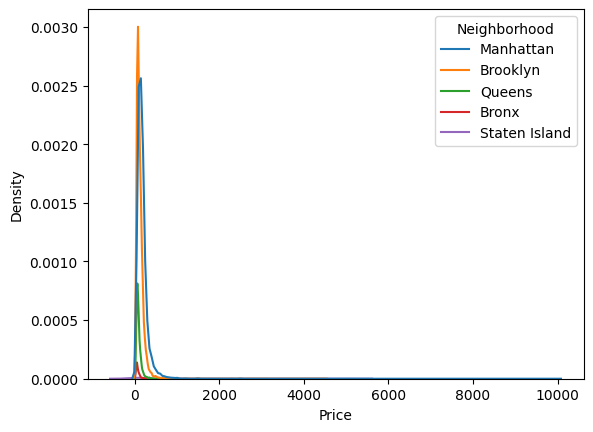

In [ ]:
# --- KDE plot for Price ---
sns.kdeplot(data=df, x="Price", hue="Neighborhood")  # distribution of price
plt.show()

In [ ]:
# --- Log transform ---
df["log_price"] = np.log(df["Price"] + 1)  # reduce skew

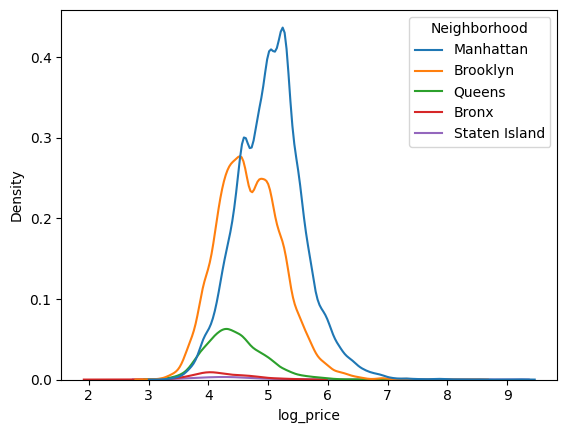

In [ ]:
# --- KDE plot for Log Price ---
sns.kdeplot(data=df, x="log_price", hue="Neighborhood")
plt.show()

In [ ]:
# Q2: Regress price on Neighborhood  by creating the appropriate dummy/one-hot-encoded variables,
# without an intercept in the linear model. 
# Compare the coefficients in the regression to the table from part 1. 
# What pattern do you see? 
# What are the coefficients in a regression of a continuous variable on one categorical variable?

# basically want to see if the regression gives the same averages computed before

# --- Create dummy variables for Neighborhood ---
# regression can't use text so we must Convert Brox, Brooklyn, Manhattan, Queens, Staten Island into dummy variables
# dummy variables are 0/1 indicators for each category

# drop_first=False keeps all columns, so we get a coefficient for each neighborhood instead of using one as a baseline
X = pd.get_dummies(df["Neighborhood"], drop_first=False)

#selects the thing we are predicting 
# X = inputs (Neighborhood); y = output (price)
y = df["Price"]

In [ ]:
# Fit linear regression model 
# fit_intercept=False means no baseline, no constant term; each coefficient will represent the average price for that neighborhood directly
model = LinearRegression(fit_intercept=False)

#this is where the model learns; looks at X (which neighborhood each row is) and y (price)
#and figures out what number should each neighborhood have
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print(model.coef_)
#[ 75.27, 127.75, 183.66, 96.86, 146.17 ] 
# These coefficients represent the average price for each neighborhood

[ 75.2764977  127.74737834 183.66428632  96.8572327  146.16666667]


In [ ]:
# shows which coefficient corresponds to which neighborhood
print(X.columns)
#Index(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']

#ANSWER: 
# The coefficients correspond to the Neighborhood columns in the same order. Each coefficient represents the average price for that neighborhood.
# These values match the averages from part 1, showing that when we regress a continuous variable on a categorical variable using dummy variables without an intercept, the coefficients are equal to the group means.

Index(['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'], dtype='str')


In [ ]:
#Q3: Repeat part 2, but leave an intercept in the linear model. 
# How do you have to handle the creation of the dummies differently? 
# What is the intercept? Interpret the coefficients. 
# How can I get the coefficients in part 2 from these new coefficients?

# with intercept, we need to drop one dummy variable to avoid the dummy variable trap.

#drop_first=True means we drop the first category (Bronx) and use it as the baseline.
X = pd.get_dummies(df["Neighborhood"], drop_first=True)

#selects the thing we are predicting 
# X = inputs (Neighborhood); y = output (price)
y = df["Price"]

In [ ]:
# Fit linear regression model with intercept

model = LinearRegression() #intercept is included by default
model.fit(X,y)

#Results
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_) 
print("Columns:", X.columns)

#The intercept = 75.27, which is the average price for the baseline category (Bronx).
# The coefficients represent the difference in average price compared to the baseline (Bronx):
# So the intercept = the average price for the Bronx, and each coefficient tells us how much more expensive that neighborhood is compared to the Bronx.

#ANSWER:
# When including an intercept, we must drop one dummy variable to avoid multicollinearity. In this case, Bronx is the baseline category since it was dropped.
#The intercept represents the average price in the Bronx, which is about 75.27. Each coefficient represents the difference in price between that neighborhood and the Bronx. For example, Manhattan is about 108.39 dollars more expensive than the Bronx on average.
#To recover the coefficients from part 2, we add each coefficient to the intercept, which gives the average price for each neighborhood.

Intercept: 75.27649769585331
Coefficients: [ 52.47088065 108.38778863  21.58073501  70.89016897]
Columns: Index(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island'], dtype='str')


In [ ]:
#Q4: Split the sample 80/20 into a training and a test set. Run a regression of Price on Review Scores Rating and Neighborhood . 
# What is the R^2 and RMSE on the test set? 
# What is the coefficient on Review Scores Rating? 
# What is the most expensive kind of property you can rent?

#asked to: split data --> train/test
#regress price on: review scores rating (numeric) and neighborhood (categorical --> dummies)
#evaluate on test set: R^2, RMSE
#Interpret coefficient on review scores rating
#Find most expensive kind of property 

#create dummy variables for Neighborhood, drop one for baseline
X = pd.get_dummies(df[["Review Scores Rating", "Neighborhood"]], drop_first=True)

#target variable
y = df["Price"]

In [ ]:
# split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Fit Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#Predictions on test set
y_pred = model.predict(X_test)

#Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R^2 on test set:", r2)
print("RMSE on test set:", rmse)

R^2 on test set: 0.045925883817350965
RMSE on test set: 140.91821103729345


In [ ]:
# Coefficients 
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})
print(coef_df)

print("Intercept:", model.intercept_)

#ANSWER:
#The R² on the test set is about 0.046, and the RMSE is about 140.92, indicating that the model does not explain much of the variation in price.
# The coefficient on Review Scores Rating is about 1.21, meaning that for each one-point increase in rating, the price increases by about $1.21, holding neighborhood constant.
#The most expensive neighborhood is Manhattan, since it has the largest positive coefficient (about 107.41) relative to the baseline (Bronx).
#Compared to the previous model, the neighborhood coefficients are smaller, suggesting that some of the differences in price across neighborhoods are explained by review scores.

                     Variable  Coefficient
0        Review Scores Rating     1.211852
1       Neighborhood_Brooklyn    51.555970
2      Neighborhood_Manhattan   107.413553
3         Neighborhood_Queens    20.198573
4  Neighborhood_Staten Island    23.454672
Intercept: -35.157344063247564


In [ ]:
#Q5: Run a regression of Price on Review Scores Rating and Neighborhood  and Property Type. 
# What is the R^2 and RMSE on the test set? 
# What is the coefficient on Review Scores Rating? 
# What is the most expensive kind of property you can rent?

#now we make the model include property type as well, which is another categorical variable that we need to convert to dummies

# create dummy variables for Neighborhood and Property Type, drop one for baseline
X = pd.get_dummies(df[["Review Scores Rating", "Neighborhood", "Property Type"]], drop_first=True)

#create target variable
y = df["Price"]

In [ ]:
# split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Fit in the model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
#Predictions on test set
y_pred = model.predict(X_test)

In [ ]:
#Evaluate model performance

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R^2 on test set:", r2)
print("RMSE on test set:", rmse)    

#R^2 on test set: 0.054242713551245325
#RMSE on test set: 140.30266238276283

R^2 on test set: 0.054242713551245325
RMSE on test set: 140.30266238276283


In [ ]:
# Coefficients
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})
print(coef_df)      

print("Intercept:", model.intercept_)

#ANSWER:
#The R² on the test set is about 0.054, and the RMSE is about 140.30, indicating that the model explains very little of the variation in price.

#The coefficient on Review Scores Rating is about 1.20, meaning that for each one-point increase in rating, the price increases by about $1.20, holding neighborhood and property type constant.

#The most expensive property type is Bungalow, since it has the largest positive coefficient (about 83.97) relative to the baseline category.

                         Variable  Coefficient
0            Review Scores Rating     1.201011
1           Neighborhood_Brooklyn    59.633702
2          Neighborhood_Manhattan   121.005520
3             Neighborhood_Queens    26.830617
4      Neighborhood_Staten Island    15.700974
5   Property Type_Bed & Breakfast   -28.703920
6              Property Type_Boat    47.070419
7          Property Type_Bungalow    83.972440
8             Property Type_Cabin    12.389621
9         Property Type_Camper/RV   -13.817125
10           Property Type_Castle   -41.810548
11           Property Type_Chalet   -30.237720
12      Property Type_Condominium    61.907162
13             Property Type_Dorm   -42.277758
14            Property Type_House    34.711346
15              Property Type_Hut  -134.604484
16       Property Type_Lighthouse   -91.438731
17             Property Type_Loft    69.891025
18            Property Type_Other    49.249761
19        Property Type_Townhouse    44.110768
20        Pro

In [ ]:
#Q6: What does the coefficient on Review Scores Rating mean if it changes from part 4 to 5?
#  Hint: Think about how multiple linear regression works.

#asking why did the coefficient on review scores rating change when you added property type
#idea: in multiple linear regressions -each coefficient is interpreted holding all other variables constant 
# what changed from 4 to 5?
# 4: controlled for neighborhood only
# 5: controlled for neighborhood and property type
# so now the model separates: effects of ratings and effects of property type 

#ANSWER:
# The coefficient on Review Scores Rating changes from part 4 to part 5 because the model now includes an additional variable, Property Type. 
# In multiple linear regression, each coefficient represents the effect of that variable while holding all other variables constant.
# In part 4, the coefficient on review scores may have captured some of the effect of property type. 
# In part 5, after adding Property Type to the model, the coefficient on review scores reflects its effect after accounting for both neighborhood and property type. 
# This change shows that some of the variation previously attributed to review scores is actually explained by property type.

In [ ]:
#Q7:We've included Neighborhood  and Property Type separately in the model. 
# How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". 
# Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus Review Scores Rating. 
# How does the slope coefficient for Review Scores Rating, the R^2and the RMSE change? 
# Do they increase significantly compares to part 5? 
# Are the coefficients in this regression just the sum of the coefficients for Neighbourhood  and Property Type from 5? 
# What is the most expensive kind of property you can rent?

# instead of treating: neighborhood, property type
# seperately commbinations like Bungalow in Manhattan, Townhouse in Queens, etc.

#create inetraction variable 
#combine neighborhood and property type into one column
df["Interaction"] = df["Neighborhood"] + "_" + df["Property Type"]

#create dummies and drop one for baseline
X = pd.get_dummies(df[["Review Scores Rating", "Interaction"]], drop_first=True)

# target variable
y = df["Price"]

In [ ]:
# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# --- Fit model ---
model = LinearRegression()
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

In [ ]:
# --- Evaluation ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("R^2:", r2)
print("RMSE:", rmse)

R^2: 0.054558809011926446
RMSE: 140.27921411459116


In [ ]:
# --- Coefficients ---
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})
print(coef_df)

print("Intercept:", model.intercept_)

#ANSWER:
#Including interaction terms allows the model to capture specific combinations of neighborhood and property type, such as a loft in Manhattan or a bungalow in Queens.
#The R² increases slightly to about 0.0546 and the RMSE decreases slightly to about 140.28 compared to part 5, indicating only a very small improvement in model performance.
#The coefficient on Review Scores Rating is about 1.20, which is very similar to the previous model, suggesting that ratings still have a small effect on price.
#The coefficients in this model are not simply the sum of the coefficients for Neighborhood and Property Type from part 5. Instead, each coefficient represents the effect of a specific combination of neighborhood and property type.
#The most expensive property is a loft in Manhattan, since it has the largest coefficient (about 285.32).

                                     Variable   Coefficient
0                        Review Scores Rating  1.199018e+00
1           Interaction_Bronx_Bed & Breakfast -2.084589e+01
2               Interaction_Bronx_Condominium  6.513447e+01
3                     Interaction_Bronx_House -4.180558e+00
4                      Interaction_Bronx_Loft  5.294650e+01
5                 Interaction_Bronx_Townhouse  3.254724e+01
6              Interaction_Brooklyn_Apartment  4.714598e+01
7        Interaction_Brooklyn_Bed & Breakfast  1.073713e+01
8                   Interaction_Brooklyn_Boat  3.012701e-12
9              Interaction_Brooklyn_Camper/RV -2.166160e+01
10                Interaction_Brooklyn_Chalet  1.435313e+01
11           Interaction_Brooklyn_Condominium  9.549213e+01
12                  Interaction_Brooklyn_Dorm  7.935002e+00
13                 Interaction_Brooklyn_House  7.992697e+01
14            Interaction_Brooklyn_Lighthouse -4.684589e+01
15                  Interaction_Brooklyn

In [ ]:
#QUESTION 2 SET

#Q1: Load cars_hw.csv. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) 
# Note this is different than normalizing: there is a text below that explains further. 
# Clean the data however you think is most appropriate

# --- Load dataset ---
df = pd.read_csv("cars_hw.csv")

# --- Check data ---
print(df.head())
print(df.describe())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
       Unnamed: 0    Make_Year  

In [ ]:
# --- Drop unnecessary column ---
# "Unnamed: 0" is just an index column and does not contain useful information
df = df.drop(columns=["Unnamed: 0"])

# --- Fix No_of_Owners ---
# This column is stored as text (e.g., "1st", "2nd"), which cannot be used in regression
# We remove the text and keep only the numeric part, then convert to integers
df["No_of_Owners"] = df["No_of_Owners"].str.replace(r"\D", "", regex=True).astype(int)

# --- Handle skewed variables ---
# Price and Mileage_Run are right-skewed (many small values, few very large ones)
# Taking the log compresses large values and makes the distribution more symmetric
df["log_price"] = np.log(df["Price"] + 1)
df["log_mileage"] = np.log(df["Mileage_Run"] + 1)

# --- Remove extreme outliers ---
# Very large prices can distort the model, so we remove the top 1% of values
price_cutoff = df["Price"].quantile(0.99)
df = df[df["Price"] < price_cutoff]

In [ ]:
# --- Check cleaned data ---
# This helps confirm that the data looks more reasonable after cleaning
print(df.describe())

#ANSWER:
#After cleaning the data, the summary statistics show that extreme values in Price have been reduced, as the maximum value decreased from about 2.94 million to about 1.98 million. This indicates that removing the top 1% of values successfully reduced the impact of outliers.

#The log transformations of Price and Mileage_Run result in more compressed distributions with smaller standard deviations, suggesting reduced skewness. This makes the variables more suitable for linear regression, as extreme values have less influence on the model.

#Overall, the cleaned data appears more balanced and appropriate for modeling.

         Make_Year   Mileage_Run  No_of_Owners  Seating_Capacity  \
count   966.000000    966.000000    966.000000        966.000000   
mean   2016.927536  41646.677019      1.167702          5.094203   
std       2.810588  24464.647066      0.384724          0.444223   
min    2011.000000   1117.000000      1.000000          4.000000   
25%    2015.000000  22624.250000      1.000000          5.000000   
50%    2017.000000  37677.000000      1.000000          5.000000   
75%    2019.000000  57987.250000      1.000000          5.000000   
max    2022.000000  99495.000000      3.000000          8.000000   

              Price   log_price  log_mileage  
count  9.660000e+02  966.000000   966.000000  
mean   7.268965e+05   13.399217    10.417238  
std    3.406196e+05    0.437111     0.735156  
min    1.880000e+05   12.144203     7.019297  
25%    4.727500e+05   13.066320    10.026820  
50%    6.625000e+05   13.403777    10.536831  
75%    8.747500e+05   13.681691    10.967996  
max    1.97

In [ ]:
#Q2:Summarize the Price variable and create a kernel density plot. 
# Use .groupby() and .describe() to summarize prices by brand (Make). 
# Make a grouped kernel density plot by Make. 
# Which car brands are the most expensive? What do prices look like in general?
#Split the data into an 80% training set and a 20% testing set.

# --- Summarize Price ---
# describe() gives count, mean, std, min, max, etc.
print(df["Price"].describe())

count    9.660000e+02
mean     7.268965e+05
std      3.406196e+05
min      1.880000e+05
25%      4.727500e+05
50%      6.625000e+05
75%      8.747500e+05
max      1.978000e+06
Name: Price, dtype: float64


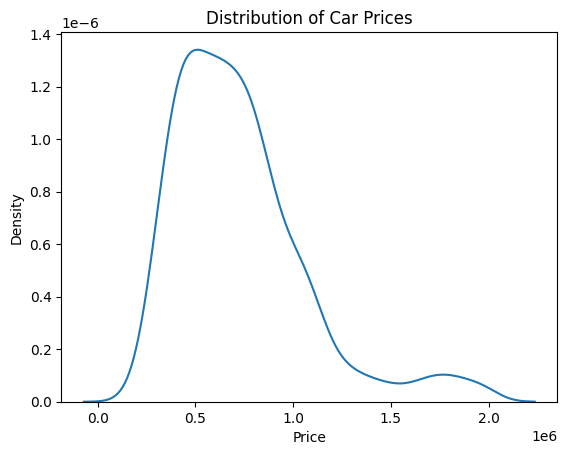

In [ ]:
#  KDE plot for Price 
# Shows distribution (shape) of price
sns.kdeplot(df["Price"])
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.show()

In [ ]:
#  Group by Make (brand) 
# groupby() groups data by brand
# describe() summarizes price within each brand
price_by_make = df.groupby("Make")["Price"].describe()
print(price_by_make)

               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        6.0  4.535000e+05  246606.366503   267000.0   288500.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Honda           73.0  7.989726e+05  266509.066586   316000.0   581000.0   
Hyundai        305.0  6.918918e+05  279159.708519   248000.0   485000.0   
Jeep             4.0  1.499500e+06  152513.387391  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  119056.709177  1369000.0  1579000.0   
MG Motors       27.0  1.830333e+06  110937.959100  1589000.0  1767000.0   
Mahindra        18.0  1.100167e+06  175549.305961   796000.0  1037000.0   
Maruti Suzuki  293.0  5.887850e+05  216019.860943   237000.0   411000.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Renault         68.0  6.6

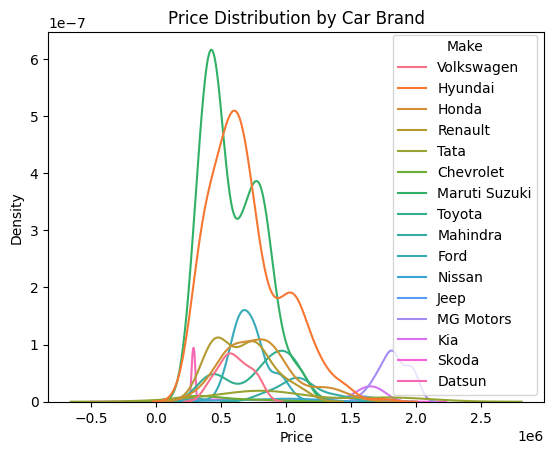

In [ ]:
#  KDE plot grouped by Make 
# Shows how price distributions differ by brand
sns.kdeplot(data=df, x="Price", hue="Make")
plt.title("Price Distribution by Car Brand")
plt.xlabel("Price")
plt.show()

#ANSWER: 
# The Price variable shows a right-skewed distribution, with most cars concentrated between about 400,000 and 900,000 and a long tail extending toward higher values. This indicates that while most cars are moderately priced, there are a few expensive cars that increase the average price.
# The kernel density plot confirms this pattern, showing a peak in the mid-price range and a gradual decline as prices increase.

# When grouping by Make, some brands have distributions shifted toward higher prices. Brands such as Jeep, MG Motors, and Skoda appear to be more expensive, as their distributions extend further to the right. In contrast, brands like Maruti Suzuki and Hyundai are more concentrated at lower price ranges.

# Overall, car prices are right-skewed, with most cars being moderately priced and a smaller number of high-priced vehicles.

In [ ]:
#Q3: Split the data into an 80% training set and a 20% testing set.

#  Train/Test Split (80/20) 
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Price"])  # predictors
y = df["Price"]                # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Q4:Make a model where you regress price on the numeric variables alone; what is the R^2 and RMSE on the training set and test set? 
# Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone
#  (you can use pd.get_dummies(); be careful of the dummy variable trap); 
# what is the R^2 and RMSE on the test set? Which model performs better on the test set? 
# Make a third model that combines all the regressors from the previous two; 
# what is the R^2 and RMSE on the test set? 
# Does the joint model perform better or worse, and by home much?

In [ ]:
#  Model 1: Numeric variables only 

# Select numeric features (these are already numbers)
X = df[["Make_Year", "Mileage_Run", "No_of_Owners", "Seating_Capacity"]]

# Target variable we want to predict
y = df["Price"]

# Split data into training (80%) and testing (20%)
# Training data is used to fit the model, testing data evaluates performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create linear regression model
model = LinearRegression()

# Fit the model (learn relationship between X and y)
model.fit(X_train, y_train)

# Make predictions on training and test data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Compute performance metrics
# R^2 measures how much variation in price is explained by the model
# RMSE measures average prediction error in dollars
print("Numeric Model Train R^2:", r2_score(y_train, y_train_pred))
print("Numeric Model Test R^2:", r2_score(y_test, y_test_pred))

print("Numeric Model Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Numeric Model Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Numeric Model Train R^2: 0.32170405868405905
Numeric Model Test R^2: 0.27211197364012485
Numeric Model Train RMSE: 283611.6053180997
Numeric Model Test RMSE: 276598.06414127885


In [ ]:
#  Model 2: Categorical variables only 

# Convert categorical variables into dummy (0/1) variables
# drop_first=True avoids multicollinearity (dummy variable trap)
X = pd.get_dummies(df[["Make", "Color", "Body_Type", "Fuel_Type", "Transmission_Type"]], drop_first=True)

# Target variable remains the same
y = df["Price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_test_pred = model.predict(X_test)

# Evaluate performance
print("Categorical Model Test R^2:", r2_score(y_test, y_test_pred))
print("Categorical Model Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Categorical Model Test R^2: 0.6212991056791745
Categorical Model Test RMSE: 199510.15862491645


In [ ]:
#  Model 3: Combined numeric + categorical variables 

# Combine numeric and categorical features into one dataset
X_num = df[["Make_Year", "Mileage_Run", "No_of_Owners", "Seating_Capacity"]]
X_cat = pd.get_dummies(df[["Make", "Color", "Body_Type", "Fuel_Type", "Transmission_Type"]], drop_first=True)

X = pd.concat([X_num, X_cat], axis=1)

# Target variable
y = df["Price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_test_pred = model.predict(X_test)

# Evaluate performance
print("Combined Model Test R^2:", r2_score(y_test, y_test_pred))
print("Combined Model Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Combined Model Test R^2: 0.7788381950832297
Combined Model Test RMSE: 152465.6155033023


In [ ]:
#ANSWER:
# The numeric-only model has a training R² of about 0.322 and a test R² of about 0.272. The RMSE is approximately 283,612 on the training set and 276,598 on the test set. This indicates that numeric variables alone explain a limited portion of the variation in car prices.

#The categorical-only model has a test R² of about 0.621 and an RMSE of about 199,510. This model performs substantially better than the numeric model, suggesting that categorical variables such as Make and Body_Type are strong predictors of price.

#The combined model has a test R² of about 0.779 and an RMSE of about 152,466. This model performs the best, as it incorporates both numeric and categorical variables.

#Overall, the combined model improves performance significantly compared to the individual models. The R² increases from 0.621 to 0.779 and the RMSE decreases from about 199,510 to 152,466, showing that combining both types of variables provides a much better fit.

In [ ]:
#Q5: Use the PolynomialFeatures function from sklearn to expand the set of numerical variables you're using in the regression. 
# As you increase the degree of the expansion, how do the R^2and RMSE change? 
# At what point does R^2 go negative on the test set? 
# For your best model with expanded features, what is the R^2 and RMSE? 
# How does it compare to your best model from part 4?

#degree 1 → original variables
#degree 2 → squares + interactions
#degree 3 → more complex terms
#Then see how performance change

In [ ]:
#  Polynomial regression with numeric variables only 

# Use the same numeric variables from the earlier model
X = df[["Make_Year", "Mileage_Run", "No_of_Owners", "Seating_Capacity"]]
y = df["Price"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Try several polynomial degrees
for degree in [1, 2, 3, 4, 5]:
    
    # PolynomialFeatures creates squared terms, cubic terms, and interactions
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    
    # Fit on training data and transform both train and test sets
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Fit linear regression model on expanded features
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predict on the test set
    y_test_pred = model.predict(X_test_poly)
    
    # Compute test performance
    r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    print("Degree:", degree)
    print("Test R^2:", r2)
    print("Test RMSE:", rmse)
    print()

#ANSWER:
# As the degree of the polynomial expansion increases, the model becomes more flexible and can capture more complex relationships. From degree 1 to degree 2 and 4, the R² increases and the RMSE decreases, indicating improved performance.

# However, after a certain point, the model begins to overfit, as seen by fluctuations in R² and RMSE for higher degrees such as 3 and 5. In this case, the R² does not become negative for any of the tested degrees.

#The best-performing polynomial model occurs at degree 4, with a test R² of about 0.308 and an RMSE of about 269,735.

#Compared to the best model from part 4 (the combined model), which had a test R² of about 0.779 and RMSE of about 152,466, the polynomial model performs significantly worse. This suggests that categorical variables provide much more predictive power than simply adding nonlinear transformations of numeric variables.

Degree: 1
Test R^2: 0.27211197364012485
Test RMSE: 276598.06414127885

Degree: 2
Test R^2: 0.30159539636537014
Test RMSE: 270938.2961103817

Degree: 3
Test R^2: 0.29674345635430255
Test RMSE: 271877.7952922088

Degree: 4
Test R^2: 0.30778490205182196
Test RMSE: 269735.0493433084

Degree: 5
Test R^2: 0.29667064522151476
Test RMSE: 271891.8692585846



In [ ]:
#Q6: For your best model so far, determine the predicted values for the test data and plot them against the true values.
# Do the predicted values and true values roughly line up along the diagonal, or not? 
# Compute the residuals/errors for the test data and create a kernel density plot. 
# Do the residuals look roughly bell-shaped around zero?
# Evaluate the strengths and weaknesses of your model.

# Use best model (combined variables) 

# Recreate combined features
X_num = df[["Make_Year", "Mileage_Run", "No_of_Owners", "Seating_Capacity"]]
X_cat = pd.get_dummies(df[["Make", "Color", "Body_Type", "Fuel_Type", "Transmission_Type"]], drop_first=True)

X = pd.concat([X_num, X_cat], axis=1)
y = df["Price"]

# Train/test split (same as before)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

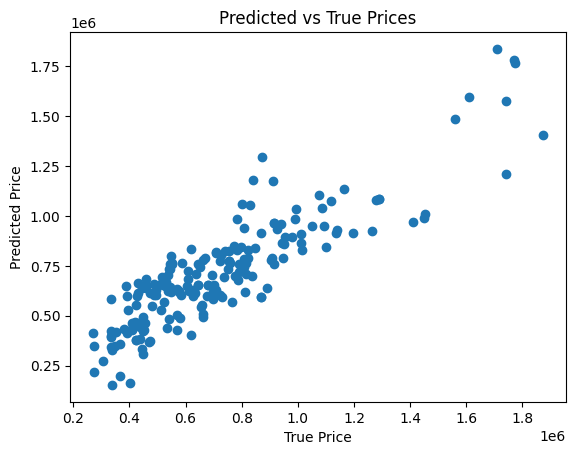

In [ ]:
#  Plot predicted vs actual values 
# If model is good, points should lie near the diagonal line
plt.scatter(y_test, y_pred)
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True Prices")
plt.show()

In [ ]:
#  Compute residuals 
# residual = actual - predicted
residuals = y_test - y_pred

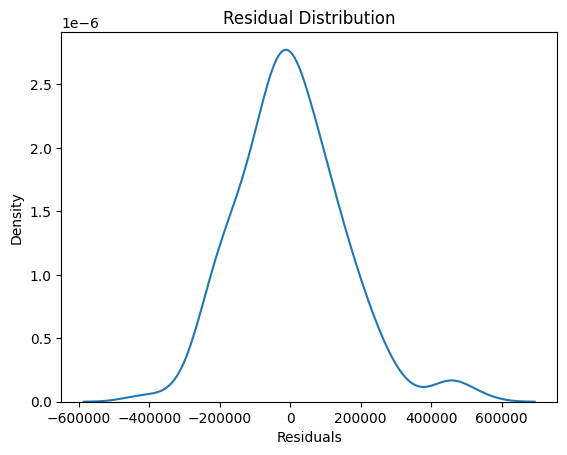

In [ ]:
#  Plot residual distribution 
# Should be roughly centered around 0 if model is good
sns.kdeplot(residuals)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

# ANSWER: 
# The predicted values and true values show a clear positive relationship, with many points roughly aligning along the diagonal. This indicates that the model captures the general pattern in car prices, although there is some spread, especially at higher price levels, suggesting less accuracy for more expensive cars.

#The residuals are centered around zero and appear approximately bell-shaped, indicating that the model’s errors are reasonably well distributed. However, there is a slight right tail, suggesting that the model occasionally underestimates higher-priced vehicles.

#A strength of the model is that it explains a large portion of the variation in price, as seen from the relatively high R² value. Additionally, the residuals being centered around zero suggests that the model is not systematically biased.

#A weakness of the model is that there is still noticeable variability in predictions, particularly for higher-priced cars, which indicates that some important factors affecting price may not be included in the model. Overall, the model performs well but could be improved by incorporating additional features or more complex relationships.

In [ ]:
#QUESTION 3 SET

#Q1: Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

# For this question, I selected a dataset on student performance factors. The dataset includes variables such as Hours_Studied, Attendance, Sleep_Hours, Motivation_Level, and other demographic and behavioral factors, with Exam_Score as the target variable.

#I chose this dataset because it contains both numeric and categorical variables, making it well-suited for applying linear regression techniques similar to those used in previous questions. It also allows for analyzing how different factors influence academic performance.

# Load dataset 
df = pd.read_csv("StudentPerformanceFactors.csv")

#  Check data 
print(df.head())
print(df.info())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [ ]:
#Q2: Clean the data and do some exploratory data analysis on key variables that interest you. 
# Pick a particular target/outcome variable and features/predictors.
# Clean data 
# Drop rows with missing values to keep things simple
df = df.dropna()

In [ ]:
#  Convert categorical variables 
# Turn all text variables into dummy (0/1) variables
df = pd.get_dummies(df, drop_first=True)

In [ ]:
#  Define target and predictors 
# Target variable (what we want to predict)
y = df["Exam_Score"]

# Predictor variables (everything else)
X = df.drop(columns=["Exam_Score"])

In [ ]:
#  Summary of target variable 
print(y.describe())

count    6378.000000
mean       67.252117
std         3.914217
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


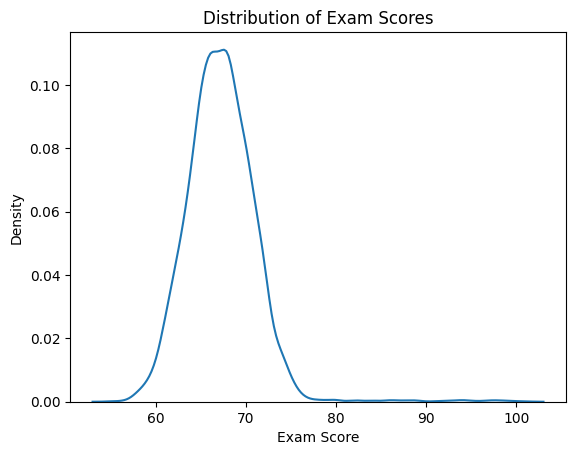

In [ ]:
#  Distribution of Exam Score 
sns.kdeplot(y)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.show()

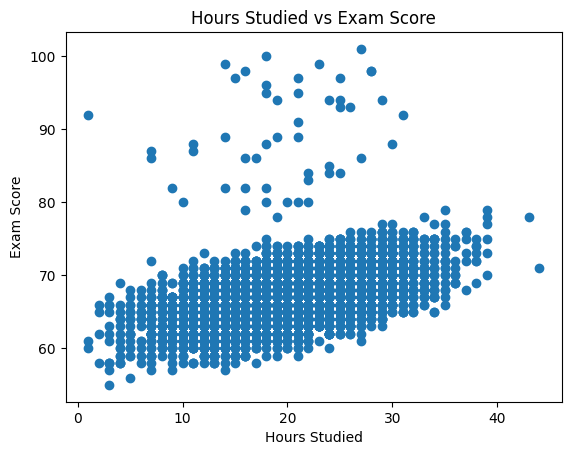

In [ ]:
# Relationship: Hours Studied vs Exam Score 
plt.scatter(df["Hours_Studied"], df["Exam_Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

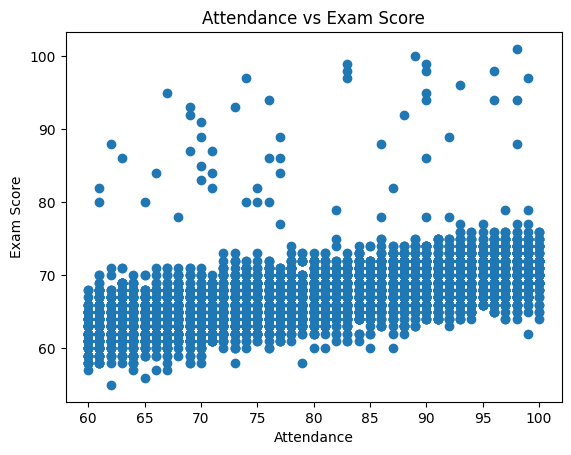

In [ ]:
#  Relationship: Attendance vs Exam Score 
plt.scatter(df["Attendance"], df["Exam_Score"])
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")
plt.show()

In [ ]:
# ANSWER: 
# I cleaned the dataset by removing observations with missing values in variables such as Teacher_Quality, Parental_Education_Level, and Distance_from_Home. This ensures that the dataset is complete and suitable for regression analysis. I also converted all categorical variables into dummy variables using one-hot encoding so they can be used in a linear regression model.
# I selected Exam_Score as the target variable, since it represents student academic performance. The predictor variables include factors such as Hours_Studied, Attendance, Sleep_Hours, Previous_Scores, and other demographic and behavioral characteristics.

# From the summary statistics, Exam_Score has a mean of about 67.25 with a standard deviation of about 3.91, indicating that most students’ scores are relatively close to the average. The distribution of exam scores appears approximately bell-shaped, with most values concentrated between about 65 and 70, and a few higher outliers.

# The scatter plot of Hours_Studied versus Exam_Score shows a positive relationship, where students who study more hours tend to have higher exam scores. Similarly, the scatter plot of Attendance versus Exam_Score also shows a positive relationship, indicating that higher attendance is associated with better performance.
#Overall, the exploratory analysis suggests that both study time and attendance are important predictors of exam scores, and the selected variables are appropriate for modeling student performance using linear regression.

In [ ]:
#3.Split the sample into an ~80% training set and a ~20% test set.

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(  X, y, test_size=0.2, random_state=42)

# Check sizes
print("Training set size:", X_train.shape[0]) #51
print("Test set size:", X_test.shape[0]) #1276

#I split the dataset into an 80% training set and a 20% test set using the train_test_split function. The training set is used to fit the linear regression model, while the test set is used to evaluate how well the model performs on unseen data.

#I used a random_state of 42 to ensure that the results are reproducible.

Training set size: 5102
Test set size: 1276


In [ ]:
#4. Run a few regressions of your target/outcome variable on a variety of features/predictors. 
# Compute the RMSE on the test set.

In [ ]:
# Model 1: Numeric variables only 
X_num = X[["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores"]]

# Split again to match features
Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_num, y, test_size=0.2, random_state=42
)

model1 = LinearRegression()
model1.fit(Xn_train, yn_train)

y_pred1 = model1.predict(Xn_test)

rmse1 = np.sqrt(mean_squared_error(yn_test, y_pred1))
print("Model 1 RMSE (numeric only):", rmse1)

Model 1 RMSE (numeric only): 2.546336227369937


In [ ]:
#Model 2: Key predictors 
X_key = X[["Hours_Studied", "Attendance", "Previous_Scores"]]

Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    X_key, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(Xk_train, yk_train)

y_pred2 = model2.predict(Xk_test)

rmse2 = np.sqrt(mean_squared_error(yk_test, y_pred2))
print("Model 2 RMSE (key variables):", rmse2)

Model 2 RMSE (key variables): 2.5452075471085824


In [ ]:
# Model 3: All variables 
model3 = LinearRegression()
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
print("Model 3 RMSE (all variables):", rmse3)

Model 3 RMSE (all variables): 2.0428563488918923


In [ ]:
# ANSWER: 
# I ran several linear regression models using different sets of predictors to evaluate how well they predict Exam_Score.

#The first model used only numeric variables such as Hours_Studied, Attendance, Sleep_Hours, and Previous_Scores. This model had an RMSE of approximately 2.55.

#The second model used a smaller set of key predictors, including Hours_Studied, Attendance, and Previous_Scores, with an RMSE of approximately 2.55 as well.

#The third model used all available predictors, including both numeric variables and dummy-coded categorical variables. This model had the lowest RMSE of approximately 2.04, indicating the best performance.

#Overall, the model that included all variables performed the best. This suggests that including additional factors such as demographic and behavioral variables improves the model’s ability to predict exam scores, even though the improvement is moderate.

In [ ]:
#5. Which model performed the best, and why?

# ANSWER: 
# The model that performed the best was the third model, which included all available predictors, including both numeric variables and dummy-coded categorical variables. This model had the lowest RMSE of approximately 2.04, compared to about 2.55 for the other models.

# This model performs better because it incorporates more information about each student, including demographic, behavioral, and school-related factors. By including these additional variables, the model is able to better capture the variation in exam scores and make more accurate predictions.

# In contrast, the models that used only numeric variables or a smaller subset of predictors had higher RMSE values, indicating less accurate predictions. Therefore, including a wider range of relevant features improves model performance.

No kernel connected

No kernel connected